# Revenue Index — Historical Benchmark

Stage 4, step 1. Builds the observed 2005-2025 revenue index that both
downstream notebooks compare their simulated paths against, and backtests the
fitted marginal models through the same production chain.

## Objective
Compute a daily, production-weighted revenue index `RI(t)` for a 1 kWp reference
PV plant in Bologna on the **observed** record, using exactly the formulas the
simulation uses, so historical and simulated values are directly comparable.

Two series are produced from the same chain:

- **actual** — observed irradiance, capture rate and temperature;
- **modelled** — the Stage-1 fitted values for the same days, which is an
  in-sample backtest of the marginal models propagated through the production
  chain rather than judged one variable at a time.

**Production chain** (all four formulas live in `model_utils.production_chain`,
so this notebook and `04_revenue_index_scenarios.ipynb` cannot drift apart):

| step | formula | units |
|---|---|---|
| effective cell temperature | `T_eff(t) = T(t) + uplift[doy(t)]` | °C |
| temperature derating | `f_temp(t) = 1 + gamma * (T_eff(t) - T_STC)` | — |
| unit energy yield | `P(t) = (GHI(t) / G_STC) * f_temp(t) * PR` | kWh/kWp/day |
| daily revenue index | `RI(t) = P(t) * CR(t)` | kWh/kWp * CR |
| annual revenue index | `RI_annual = sum over the year of RI(t)` | kWh/kWp * CR |

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Code/Models/Temperature/noct_uplift_params.pkl` | Production chain on observed and on fitted inputs, then annual aggregation | `Data/Results/ri_annual_results_hist.parquet` |
| `Data/Modelled/df_solar_modelled.parquet` (`GHI_obs`, `GHI_cs`) | | |
| `Data/Modelled/df_cr_modelled.parquet` (`capture_rate`) | | |
| `Data/Modelled/df_temperature_modeled.parquet` (`t2m_mean`) | | |

## Decision Log

The production-chain constants are the study's **stated assumptions**. They are
deliberate simplifications, not omissions: `RI` is used as a *relative* index and
in hedge ratios, where any constant multiplicative factor cancels. What does not
cancel is seasonal shape.

| # | Decision | Effect on absolute level |
|---|---|---|
| D1 | `PR = 0.80` applied *in addition to* `f_temp` | A literature/PVGIS performance ratio already embeds roughly 4-6% thermal derating, so temperature loss is counted twice here; `PR` must be read as **ex-temperature**. Yield biased **low** by about 5%. No source is cited for the 0.80 figure itself — label it illustrative or cite a PVGIS/datasheet reference before treating it as final. |
| D2 | `GAMMA = -0.0043 /°C` (monocrystalline Si) | Standard datasheet value for the technology; not independently sourced in this repository. Held in `model_utils` so the notebooks that call the production chain cannot disagree on it. |
| D3 | Irradiance is horizontal (`GHI`), not plane-of-array | A fixed tilted array in Bologna receives roughly 1.10-1.15x GHI, with a seasonal profile a constant factor cannot reproduce. Yield biased **low** by 10-15%. |
| D4 | No panel degradation, availability loss, or inverter clipping over the 25-year horizon | 0.4-0.55%/yr would compound to about 12% by 2050, so the 2050 yield is biased **high**. |
| D5 | NOCT form `(NOCT-20)/800` assumes 1 m/s wind | A Faiman model using ERA5 wind would fit better. Small, seasonal effect. See `Modelling/03_noct_uplift.ipynb`, which owns this calibration. |
| D6 | `f_temp` applied to a **daily** irradiance total, not convolved hour by hour | The irradiance-weighted uplift calibration exists precisely to compensate for this aggregation. Small effect. |
| D7 | The modelled series uses **in-sample fitted values**, not a holdout | This is a specification check — does the fitted chain reproduce the observed distribution — not a forecast-accuracy claim. Out-of-sample accuracy is assessed in the Stage-1 marginal notebooks, each of which holds out its own test window. |
| D8 | The **observed** series, not the modelled one, is the benchmark exported for downstream use | The fitted irradiance series is biased about 12% high by Jensen's inequality: the inverse rescaled-logit is convex, and fitted values carry only the ARMA-explained share of the variance. The diagnostic below quantifies it. The simulation does not inherit this bias, because it restores the full innovation distribution before inverting. |

The capture-rate decline that drives `RI` down to 2050 is unaffected by D1-D6,
since it enters multiplicatively through `CR` and is untouched by any
production-chain assumption above.

## Setup

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde, ks_2samp

sys.path.append(str(Path("..").resolve()))
from model_utils import (find_project_root, production_chain,
                         uplift_for_calendar, G_STC, T_STC, GAMMA, PR, NOCT)

# Suppress only the known pandas deprecations. A blanket
# filterwarnings("ignore") would also hide RuntimeWarnings (overflow,
# divide-by-zero) raised inside the production chain below.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# -- paths ---------------------------------------------------------------------
ROOT          = find_project_root()
data_modelled = ROOT / "Data" / "Modelled"
data_cleaned  = ROOT / "Data" / "Cleaned"
data_results  = ROOT / "Data" / "Results"
models_path   = ROOT / "Code" / "Models"
data_results.mkdir(parents=True, exist_ok=True)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("-- Configuration -----------------------------------------------")
print(f"  G_STC = {G_STC} W/m2    T_STC = {T_STC} C")
print(f"  gamma = {GAMMA} /C      PR = {PR}      NOCT = {NOCT} C")
print(f"  (all imported from model_utils -- see D2)")
print(f"  data_results : {data_results}")

-- Configuration -----------------------------------------------
  G_STC = 1000.0 W/m2    T_STC = 25.0 C
  gamma = -0.0043 /C      PR = 0.8      NOCT = 45.0 C
  (all imported from model_utils -- see D2)
  data_results : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Results


### Thermal uplift profile

Calibrated in `Modelling/03_noct_uplift.ipynb` and read here as a normal
upstream artifact. The profile is deterministic and seasonal: daylight cell
temperature runs above the 24-hour mean, by most in summer.

In [3]:
# -- load the NOCT seasonal uplift --------------------------------------------
noct_path = models_path / "Temperature" / "noct_uplift_params.pkl"
if not noct_path.exists():
    raise FileNotFoundError(
        f"{noct_path} not found. Run Code/Modelling/03_noct_uplift.ipynb, "
        f"which is the only notebook that writes it."
    )
with open(noct_path, "rb") as f:
    noct_params = pickle.load(f)

uplift_by_doy = noct_params["uplift_by_doy"]

print("-- Thermal uplift ----------------------------------------------")
print(f"  Source   : {noct_path.name}")
print(f"  Entries  : {len(uplift_by_doy)} day-of-year")
print(f"  Calibrated on {noct_params['calibration_start']} -> "
      f"{noct_params['calibration_end']}")
print(f"  Mean     : {np.mean(list(uplift_by_doy.values())):.2f} C")
print(f"  Range    : [{min(uplift_by_doy.values()):.2f}, "
      f"{max(uplift_by_doy.values()):.2f}] C")

# The chain below is only valid if the profile is the seasonal, strictly
# positive one 03_noct_uplift asserts it to be. Re-check the two properties this
# notebook actually depends on, in case a stale pickle is on disk.
_jja = np.mean([uplift_by_doy[d] for d in range(172, 265)])
_djf = np.mean([uplift_by_doy[d]
                for d in list(range(1, 60)) + list(range(335, 367))])
assert min(uplift_by_doy.values()) > 0 and _jja > _djf, (
    f"STOP -- uplift profile is not seasonal-positive (JJA {_jja:.2f} C, "
    f"DJF {_djf:.2f} C). Re-run Modelling/03_noct_uplift.ipynb."
)
print(f"  JJA {_jja:.2f} C > DJF {_djf:.2f} C  OK")

-- Thermal uplift ----------------------------------------------
  Source   : noct_uplift_params.pkl
  Entries  : 366 day-of-year
  Calibrated on 2005-01-01 -> 2025-12-31
  Mean     : 16.02 C
  Range    : [8.72, 22.71] C
  JJA 21.15 C > DJF 10.13 C  OK


## Observed Record

| quantity | source |
|---|---|
| daily GHI total | `df_solar_modelled.parquet` -> `GHI_obs` (Wh/m²) |
| capture rate | `df_cr_modelled.parquet` -> `capture_rate` |
| daily mean temperature | `df_temperature_modeled.parquet` -> `t2m_mean` |

In [4]:
print("── Historical benchmark: observed inputs ────────────────────────")

# ── daily observed irradiance ─────────────────────────────────────────────────
# NOTE: df_cr_modelled.parquet carries prices and capture rate only — it has no
# irradiance column. Daily GHI totals live in df_solar_modelled.parquet as
# GHI_obs (Wh/m², date on the index), which is the same quantity and unit as
# the simulated GHI_sim.
df_solar_hist = pd.read_parquet(data_modelled / "df_solar_modelled.parquet")
df_solar_hist = df_solar_hist.reset_index()
df_solar_hist["date"] = pd.to_datetime(df_solar_hist["date"])
df_solar_hist = df_solar_hist.sort_values("date").reset_index(drop=True)

df_cr_hist = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_hist["date"] = pd.to_datetime(df_cr_hist["date"])
df_cr_hist = df_cr_hist.sort_values("date").reset_index(drop=True)

df_temp_hist = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_hist["date"] = pd.to_datetime(df_temp_hist["date"])
df_temp_hist = df_temp_hist.sort_values("date").reset_index(drop=True)

print(f"  Solar hist: {len(df_solar_hist)} rows  "
      f"{df_solar_hist['date'].min().date()} → "
      f"{df_solar_hist['date'].max().date()}")
print(f"  CR hist   : {len(df_cr_hist)} rows  "
      f"{df_cr_hist['date'].min().date()} → "
      f"{df_cr_hist['date'].max().date()}")
print(f"  Temp hist : {len(df_temp_hist)} rows  "
      f"{df_temp_hist['date'].min().date()} → "
      f"{df_temp_hist['date'].max().date()}")

# ── column names ──────────────────────────────────────────────────────────────
ghi_hist_col = "GHI_obs"       # Wh/m² daily GHI total
cr_hist_col  = "capture_rate"  # observed daily capture rate
t_hist_col   = "t2m_mean"      # 24-hour daily mean temperature °C

for col, df, label in [
    (ghi_hist_col, df_solar_hist, "df_solar_modelled"),
    (cr_hist_col,  df_cr_hist,    "df_cr_modelled"),
    (t_hist_col,   df_temp_hist,  "df_temperature_modeled"),
]:
    if col not in df.columns:
        raise KeyError(
            f"Column {col!r} not found in {label}. "
            f"Available: {list(df.columns)}"
        )

print(f"  GHI col   : '{ghi_hist_col}'  (df_solar_modelled)")
print(f"  CR col    : '{cr_hist_col}'  (df_cr_modelled)")
print(f"  T col     : '{t_hist_col}'  (df_temperature_modeled)")

# ── merge on date ─────────────────────────────────────────────────────────────
df_hist = df_solar_hist[["date", ghi_hist_col]].copy()
df_hist = df_hist.merge(df_cr_hist[["date", cr_hist_col]], on="date", how="inner")
df_hist = df_hist.merge(df_temp_hist[["date", t_hist_col]], on="date", how="inner")
df_hist = df_hist.rename(columns={
    ghi_hist_col: "GHI_hist",
    cr_hist_col:  "CR_hist",
    t_hist_col:   "T_hist",
})

n_before = len(df_hist)
df_hist  = df_hist.dropna(
    subset=["GHI_hist", "CR_hist", "T_hist"]
).copy().reset_index(drop=True)
if n_before > len(df_hist):
    print(f"  Dropped {n_before - len(df_hist)} rows with NaN values")

df_hist["year"]  = df_hist["date"].dt.year
df_hist["month"] = df_hist["date"].dt.month
df_hist["doy"]   = df_hist["date"].dt.dayofyear

print(f"\n  Merged historical dataset:")
print(f"    Rows  : {len(df_hist)}")
print(f"    Range : {df_hist['date'].min().date()} → "
      f"{df_hist['date'].max().date()}")
print(f"    GHI   : mean={df_hist['GHI_hist'].mean():.1f} Wh/m²")
print(f"    CR    : mean={df_hist['CR_hist'].mean():.4f}  "
      f"range [{df_hist['CR_hist'].min():.3f}, {df_hist['CR_hist'].max():.3f}]")
print(f"    T     : mean={df_hist['T_hist'].mean():.2f}°C")

# ── unit check: GHI must be a DAILY TOTAL in Wh/m2 ───────────────────────────
# An absolute plausibility band, not a comparison against another artifact:
# this notebook does not load the simulation, so the check must stand on its
# own. Bologna's daily GHI total averages roughly 3,900 Wh/m2; an hourly mean
# would land near 170 and a J/m2 figure near 1.4e7, so either mistake is
# caught by a wide band.
_ghi_mean = float(df_hist["GHI_hist"].mean())
assert 2_000 < _ghi_mean < 6_500, (
    f"STOP — mean daily GHI is {_ghi_mean:,.0f}, outside the plausible "
    f"[2,000, 6,500] Wh/m2 band for Bologna. Check that GHI_obs is a daily "
    f"TOTAL in Wh/m2 and not an hourly mean or a J/m2 figure."
)
print(f"    GHI daily mean: {_ghi_mean:,.0f} Wh/m2  ✓ plausible daily total")

── Historical benchmark: observed inputs ────────────────────────


  Solar hist: 7670 rows  2005-01-01 → 2025-12-31
  CR hist   : 7670 rows  2005-01-01 → 2025-12-31
  Temp hist : 7670 rows  2005-01-01 → 2025-12-31
  GHI col   : 'GHI_obs'  (df_solar_modelled)
  CR col    : 'capture_rate'  (df_cr_modelled)
  T col     : 't2m_mean'  (df_temperature_modeled)

  Merged historical dataset:
    Rows  : 7670
    Range : 2005-01-01 → 2025-12-31
    GHI   : mean=4085.2 Wh/m²
    CR    : mean=0.9554  range [0.313, 1.363]
    T     : mean=13.30°C
    GHI daily mean: 4,085 Wh/m2  ✓ plausible daily total


### Historical revenue index

In [5]:
# ── production chain on the observed record ──────────────────────────────────
# One call to the shared implementation (model_utils.production_chain), which is
# also what 04_revenue_index_scenarios.ipynb calls, so the two cannot disagree
# on GAMMA (D2) the way three separate copies of this formula once did.
#
# This one call also carries D3 (GHI is horizontal, not plane-of-array), D4 (no
# degradation/availability/clipping over the horizon) and D6 (f_temp applied to
# a daily total, not convolved hour by hour) -- see the Decision Log above for
# each assumption's direction and rough magnitude of bias.
df_hist["uplift"] = uplift_for_calendar(uplift_by_doy, df_hist["doy"].values)

_chain = production_chain(ghi=df_hist["GHI_hist"],
                          t_amb=df_hist["T_hist"],
                          uplift=df_hist["uplift"])
df_hist["T_eff"]  = _chain["T_eff"]
df_hist["f_temp"] = _chain["f_temp"]
df_hist["P_hist"] = _chain["P"]

# ── daily RI ──────────────────────────────────────────────────────────────────
df_hist["RI_hist"] = df_hist["P_hist"] * df_hist["CR_hist"]

print(f"\n  Historical RI daily statistics:")
ri_nz_hist = df_hist.loc[df_hist["RI_hist"] > 0, "RI_hist"]
print(f"    mean (RI>0) = {ri_nz_hist.mean():.4f}")
print(f"    p5  (RI>0)  = {ri_nz_hist.quantile(0.05):.4f}")
print(f"    p50 (RI>0)  = {ri_nz_hist.quantile(0.50):.4f}")
print(f"    p95 (RI>0)  = {ri_nz_hist.quantile(0.95):.4f}")

# ── aggregate to annual ───────────────────────────────────────────────────────
df_hist_annual = (
    df_hist.groupby("year")
    .agg(
        RI_annual    = ("RI_hist",  "sum"),
        P_annual     = ("P_hist",   "sum"),
        CR_annual    = ("CR_hist",  "mean"),
        T_annual     = ("T_hist",   "mean"),
        T_eff_annual = ("T_eff",    "mean"),
        GHI_annual   = ("GHI_hist", "sum"),
        n_days       = ("date",     "count"),
    )
    .reset_index()
)

print(f"\n  Historical annual RI:")
print(f"  {'Year':>6}  {'RI_annual':>10}  {'P_annual':>10}  "
      f"{'CR_mean':>9}  {'n_days':>7}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  "
      f"{'-'*9}  {'-'*7}")
for _, row in df_hist_annual.iterrows():
    print(f"  {int(row['year']):>6}  "
          f"{row['RI_annual']:>10.2f}  "
          f"{row['P_annual']:>10.2f}  "
          f"{row['CR_annual']:>9.4f}  "
          f"{int(row['n_days']):>7}")


  Historical RI daily statistics:
    mean (RI>0) = 2.9909
    p5  (RI>0)  = 0.5263
    p50 (RI>0)  = 2.8043
    p95 (RI>0)  = 5.8752

  Historical annual RI:
    Year   RI_annual    P_annual    CR_mean   n_days
  ------  ----------  ----------  ---------  -------
    2005     1149.85     1109.79     1.0086      365
    2006     1178.41     1139.23     1.0035      365
    2007     1184.64     1157.02     0.9922      365
    2008     1138.93     1111.85     1.0005      366
    2009     1147.28     1116.72     1.0070      365
    2010     1091.13     1079.24     0.9946      365
    2011     1179.19     1199.15     0.9744      365
    2012     1074.12     1164.63     0.9223      366
    2013      980.59     1092.17     0.9134      365
    2014      988.19     1083.89     0.9225      365
    2015     1100.74     1150.69     0.9535      365
    2016     1067.22     1110.95     0.9600      366
    2017     1161.28     1213.66     0.9578      365
    2018     1057.17     1107.63     0.9585  

## Model Backtest

The same chain applied to the Stage-1 **fitted** values for the same days, so
the marginal models are judged on the quantity the study actually uses rather
than one variable at a time (D7).

In [6]:
print("── Model backtest: fitted vs observed (2005–2025) ───────────────")
# D7: in-sample fitted values, not a holdout -- a specification check on
# whether the fitted chain reproduces the observed distribution, not a
# forecast-accuracy claim (each Stage-1 notebook holds out its own test window).

# --- merge historical CR and temperature data --------------------------------
# The three Stage-1 frames, re-read here with the fitted columns the observed
# section does not need.
df_cr_fit = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_fit["date"] = pd.to_datetime(df_cr_fit["date"])
df_solar_fit = pd.read_parquet(data_modelled / "df_solar_modelled.parquet").reset_index()
df_solar_fit["date"] = pd.to_datetime(df_solar_fit["date"])
df_temp_fit = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_fit["date"] = pd.to_datetime(df_temp_fit["date"])

# The fitted GHI needs the solar model's ARMA output and seasonal basis.
from statsmodels.tsa.arima.model import ARIMAResults
import json as _json
arma_result = ARIMAResults.load(str(models_path / "GHI - KT" / "ghi_arma_result.pkl"))
with open(models_path / "GHI - KT" / "ghi_seasonal_coeffs.pkl", "rb") as f:
    a_seasonal = np.array(pickle.load(f))
with open(models_path / "GHI - KT" / "model_meta.json", "r") as f:
    _meta = _json.load(f)
alpha_kt = float(_meta["logit_transform"]["alpha"])
beta_kt  = float(_meta["logit_transform"]["beta"])

_df_h = df_cr_fit[["date", "year", "capture_rate", "CR_seasonal_full", "CR_resid", "u_s"]].copy()
_df_h = _df_h.merge(
    df_solar_fit[["date", "GHI_obs", "GHI_cs"]].rename(
        columns={"GHI_obs": "ghi_sum", "GHI_cs": "ghi_cs_sum"}),
    on="date", how="left"
).merge(
    df_temp_fit[["date", "t2m_mean", "fourier_fit", "ar2_resid"]],
    on="date", how="inner"
).sort_values("date").reset_index(drop=True)

# --- GHI_modelled: ARMA fitted values -> inverse logit -> Kt -> GHI ----------
_doy   = _df_h["date"].dt.dayofyear.values
_t_rad = 2.0 * np.pi * _doy / 365.0
_Y_bar = (a_seasonal[0]
          + a_seasonal[1] * np.cos(_t_rad)
          + a_seasonal[2] * np.sin(_t_rad))

_fv = pd.Series(
    arma_result.fittedvalues.values,
    index=pd.to_datetime(arma_result.fittedvalues.index),
    name="Ytilde_fitted"
)
_df_h = _df_h.merge(_fv.rename_axis("date").reset_index(), on="date", how="left")

_Yt     = _df_h["Ytilde_fitted"].values + _Y_bar
_Xp     = 1.0 / (1.0 + np.exp(-_Yt))
_Kt_fit = np.clip(1.0 - (alpha_kt + beta_kt * _Xp), 0.0, 1.0)

_df_h["GHI_actual"]   = _df_h["ghi_sum"].values
_df_h["GHI_modelled"] = _Kt_fit * _df_h["ghi_cs_sum"].values

# --- T_modelled: Fourier deterministic fit (fourier_fit = seasonal + trend) --
_df_h["T_actual"]   = _df_h["t2m_mean"].values
_df_h["T_modelled"] = _df_h["fourier_fit"].values

# --- CR_modelled: seasonal mean + SARIMA fitted residuals --------------------
# SARIMA_fitted = CR_resid - u_s  (u_s = SARIMA innovations)
# Matches the in-sample reconstruction in Capture Price Model notebook
_df_h["CR_actual"]   = _df_h["capture_rate"].values
_df_h["CR_modelled"] = (
    _df_h["CR_seasonal_full"] + _df_h["CR_resid"].fillna(0) - _df_h["u_s"].fillna(0)
).values

# --- P and RI (actual and modelled) ------------------------------------------
# Same shared chain as the observed section above, so "actual" here reproduces
# RI_hist exactly rather than approximating it with a second implementation.
_upl = uplift_for_calendar(uplift_by_doy, _doy)
_df_h["P_actual"]   = production_chain(_df_h["GHI_actual"].values,
                                       _df_h["T_actual"].values, _upl)["P"]
_df_h["P_modelled"] = production_chain(_df_h["GHI_modelled"].values,
                                       _df_h["T_modelled"].values, _upl)["P"]

_df_h["RI_actual"]   = _df_h["P_actual"].values   * _df_h["CR_actual"].values
_df_h["RI_modelled"] = _df_h["P_modelled"].values * _df_h["CR_modelled"].values

# --- output dataframe --------------------------------------------------------
df_hist_reconstructed = _df_h[[
    "date", "year",
    "GHI_actual", "GHI_modelled",
    "T_actual",   "T_modelled",
    "CR_actual",  "CR_modelled",
    "P_actual",   "P_modelled",
    "RI_actual",  "RI_modelled",
]].copy()

# --- summary -----------------------------------------------------------------
_yr0, _yr1 = int(df_hist_reconstructed["year"].min()), int(df_hist_reconstructed["year"].max())
print(f"  df_hist_reconstructed: {len(df_hist_reconstructed):,} rows  ({_yr0}–{_yr1})")
print()
print(f"  {'Var':<5}  {'Mean actual':>13}  {'Mean modelled':>13}  {'Corr':>7}  {'NaN mod':>8}")
print(f"  {'-'*5}  {'-'*13}  {'-'*13}  {'-'*7}  {'-'*8}")
for _tag, _ca, _cm in [("GHI","GHI_actual","GHI_modelled"),
                        ("T",  "T_actual",  "T_modelled"),
                        ("CR", "CR_actual", "CR_modelled"),
                        ("P",  "P_actual",  "P_modelled"),
                        ("RI", "RI_actual", "RI_modelled")]:
    _a  = df_hist_reconstructed[_ca].values
    _m  = df_hist_reconstructed[_cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    _c  = float(np.corrcoef(_a[_ok], _m[_ok])[0, 1]) if _ok.sum() > 2 else np.nan
    _nn = int((~np.isfinite(_m)).sum())
    print(f"  {_tag:<5}  {np.nanmean(_a):>13.4f}  {np.nanmean(_m):>13.4f}  "
          f"{_c:>7.4f}  {_nn:>8d}")

── Model backtest: fitted vs observed (2005–2025) ───────────────


  df_hist_reconstructed: 7,670 rows  (2005–2025)

  Var      Mean actual  Mean modelled     Corr   NaN mod
  -----  -------------  -------------  -------  --------
  GHI        4085.1976      4580.1215   0.8789         0
  T            13.2999        13.2999   0.9442         0
  CR            0.9554         0.9553   0.7734         0
  P             3.1228         3.5076   0.8639         0
  RI            2.9909         3.3681   0.8744         0


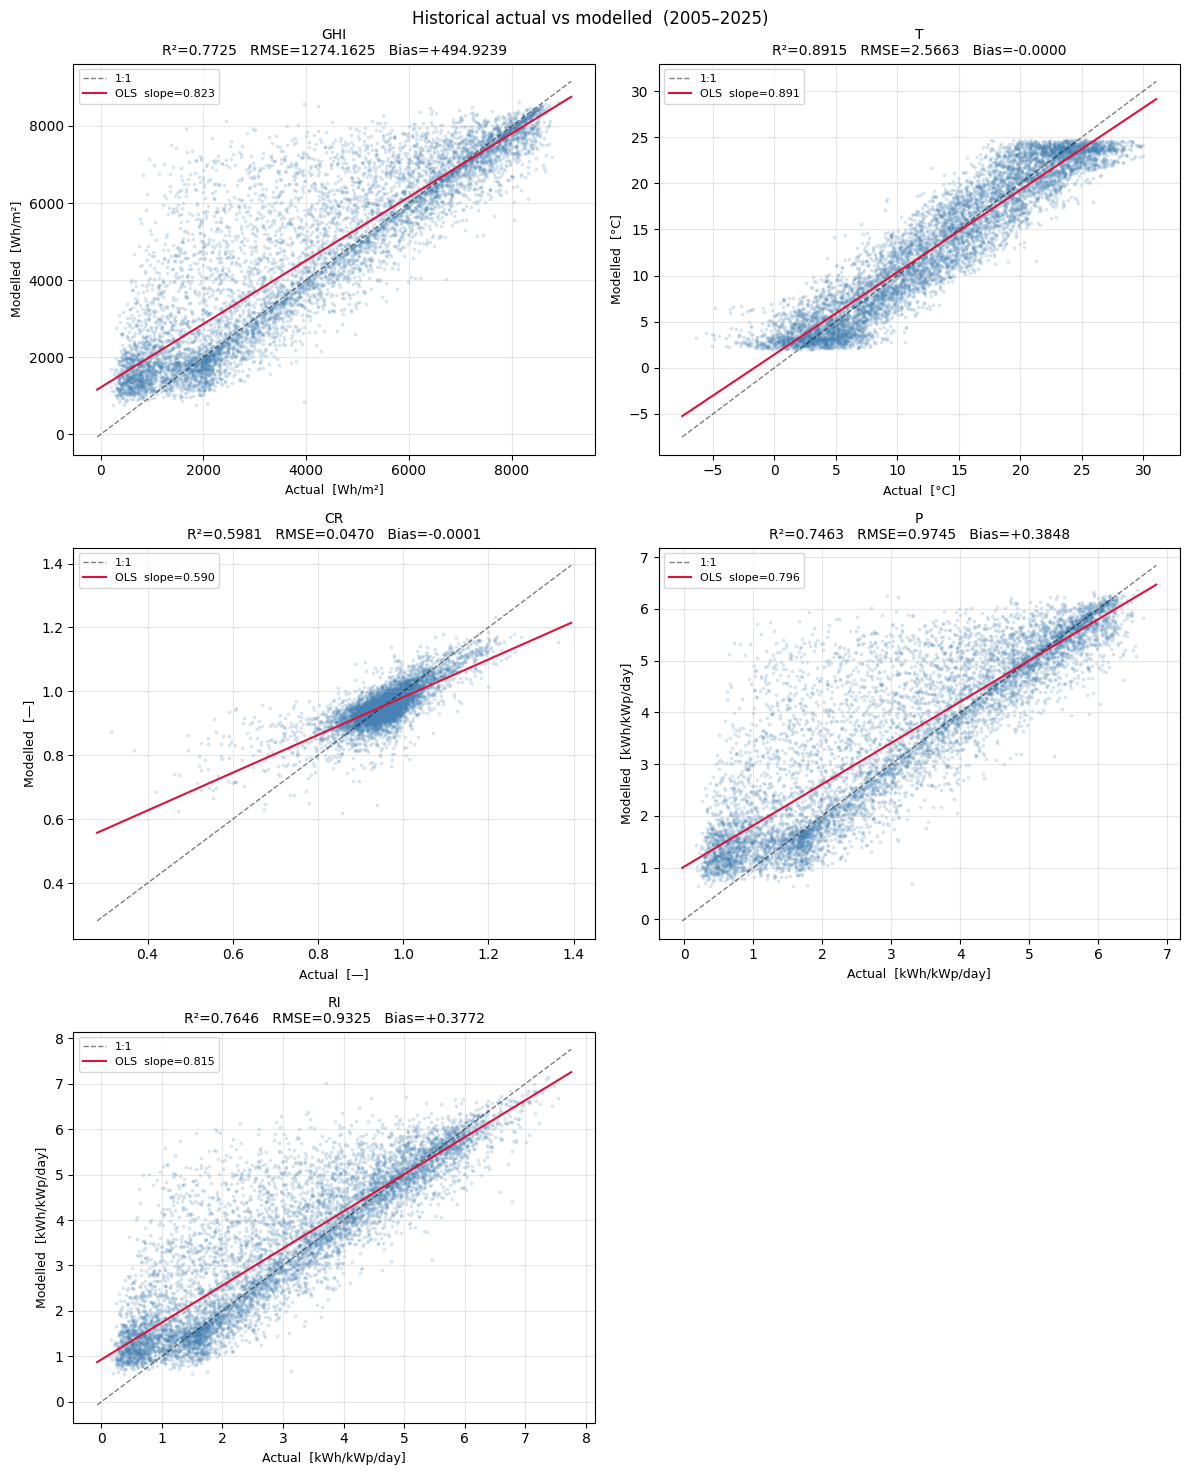

In [7]:
# =============================================================================
# Scatter: actual vs modelled (2005–2025)
# =============================================================================
_vars = [
    ("GHI", "GHI_actual", "GHI_modelled", "Wh/m²"),
    ("T",   "T_actual",   "T_modelled",   "°C"),
    ("CR",  "CR_actual",  "CR_modelled",  "—"),
    ("P",   "P_actual",   "P_modelled",   "kWh/kWp/day"),
    ("RI",  "RI_actual",  "RI_modelled",  "kWh/kWp/day"),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes_flat = axes.flatten()

for ax, (tag, ca, cm, unit) in zip(axes_flat, _vars):
    _a = df_hist_reconstructed[ca].values
    _m = df_hist_reconstructed[cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    x, y = _a[_ok], _m[_ok]

    sl, ic, r, *_ = stats.linregress(x, y)
    r2   = float(r ** 2)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    bias = float(np.mean(y - x))

    _pad = (x.max() - x.min()) * 0.03
    _xl  = np.array([x.min() - _pad, x.max() + _pad])

    ax.scatter(x, y, s=3, alpha=0.15, color="steelblue", rasterized=True)
    ax.plot(_xl, _xl,           "k--", lw=1.0, alpha=0.5, label="1:1")
    ax.plot(_xl, ic + sl * _xl, color="crimson", lw=1.5,
            label=f"OLS  slope={sl:.3f}")
    ax.set_xlabel(f"Actual  [{unit}]", fontsize=9)
    ax.set_ylabel(f"Modelled  [{unit}]", fontsize=9)
    ax.set_title(
        f"{tag}\nR²={r2:.4f}   RMSE={rmse:.4f}   Bias={bias:+.4f}",
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes_flat[-1].set_visible(False)  # hide unused 6th panel

fig.suptitle("Historical actual vs modelled  (2005–2025)  ", fontsize=12)
fig.tight_layout()
plt.show()

> **Takeaway.** Points cluster along the 1:1 line for all five variables, with the OLS slope close to 1 in each panel -- the fitted chain tracks the observed series conditionally, day by day, not just on average.

  Period : 2015–2025  (n=4,018 days)

  Var     KS stat    p-value        P5     P10     P25     P50     P75     P90     P95   (mod - act)
  -----  --------  ---------  ------  ------  ------  ------  ------  ------  ------


  GHI      0.1100     0.0000  +686.609  +665.290  +293.023  +811.975  +461.127  -0.363  -141.154


  T        0.0791     0.0000  +0.831  +0.046  -0.200  +0.076  +0.200  -0.406  -1.513


  CR       0.1187     0.0000  +0.021  +0.006  -0.000  -0.007  -0.012  -0.010  -0.008


  P        0.1157     0.0000  +0.594  +0.554  +0.238  +0.621  +0.286  -0.000  -0.080


  RI       0.1157     0.0000  +0.556  +0.526  +0.209  +0.581  +0.359  +0.064  -0.029


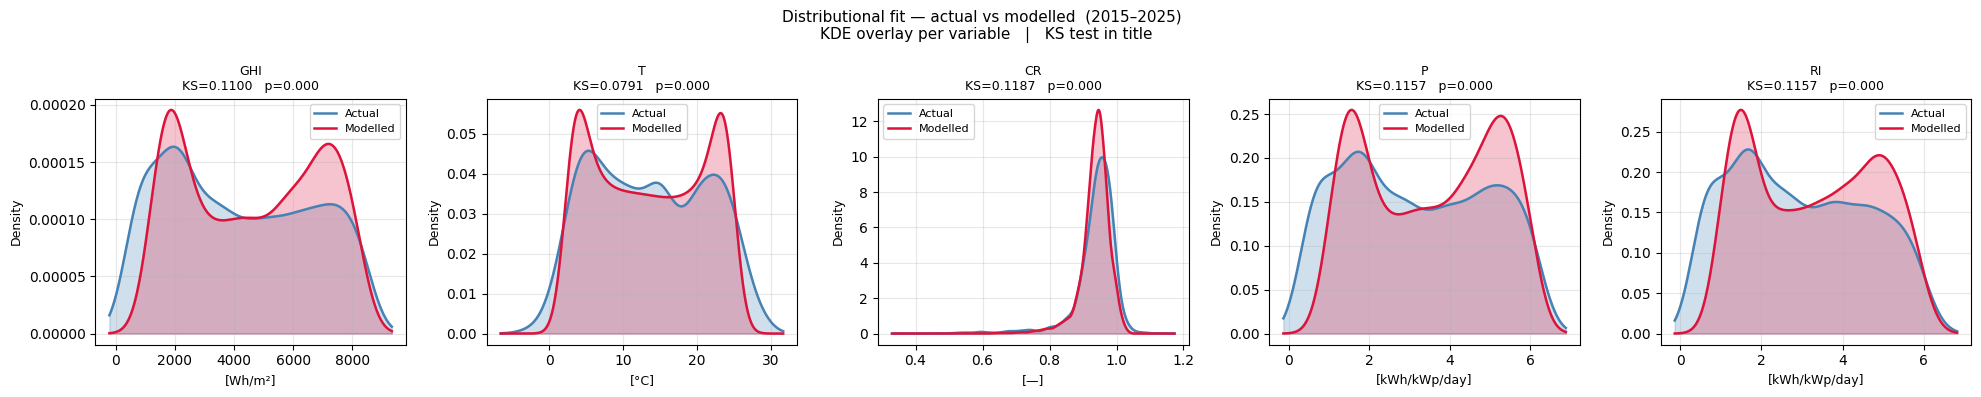


                   P5      P10      P25      P50      P75      P90      P95
  GHI act     707.719  989.653  2000.057  3876.176  6317.552  7639.922  8088.896
  GHI mod     1394.328  1654.943  2293.080  4688.151  6778.679  7639.559  7947.743
  GHI diff    +686.609  +665.290  +293.023  +811.975  +461.127   -0.363  -141.154

  T act         2.281    3.533    6.742   13.396   20.490   24.149   25.719
  T mod         3.111    3.579    6.542   13.472   20.690   23.742   24.206
  T diff       +0.831   +0.046   -0.200   +0.076   +0.200   -0.406   -1.513

  CR act        0.839    0.885    0.920    0.949    0.974    0.992    1.003
  CR mod        0.860    0.890    0.920    0.943    0.962    0.982    0.995
  CR diff      +0.021   +0.006   -0.000   -0.007   -0.012   -0.010   -0.008

  P act         0.577    0.826    1.657    3.029    4.758    5.624    5.932
  P mod         1.172    1.380    1.895    3.650    5.044    5.624    5.852
  P diff       +0.594   +0.554   +0.238   +0.621   +0.286   -0.000

In [8]:
# =============================================================================
# Distributional fit: actual vs modelled (2015–2025)
# KDE overlay + percentile calibration + KS test per variable
# =============================================================================
DIST_START = 2015

_df_dist = df_hist_reconstructed[df_hist_reconstructed["year"] >= DIST_START].copy()

_vars = [
    ("GHI", "GHI_actual", "GHI_modelled", "Wh/m²"),
    ("T",   "T_actual",   "T_modelled",   "°C"),
    ("CR",  "CR_actual",  "CR_modelled",  "—"),
    ("P",   "P_actual",   "P_modelled",   "kWh/kWp/day"),
    ("RI",  "RI_actual",  "RI_modelled",  "kWh/kWp/day"),
]
_pcts = [5, 10, 25, 50, 75, 90, 95]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

print(f"  Period : {DIST_START}–2025  (n={len(_df_dist):,} days)")
print()
print(f"  {'Var':<5}  {'KS stat':>8}  {'p-value':>9}  "
      + "".join(f"  {'P'+str(p):>6}" for p in _pcts) + "   (mod - act)")
print(f"  {'-'*5}  {'-'*8}  {'-'*9}  " + "  ".join(["-"*6] * len(_pcts)))

for ax, (tag, ca, cm, unit) in zip(axes, _vars):
    _a = _df_dist[ca].values
    _m = _df_dist[cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    x, y = _a[_ok], _m[_ok]

    _lo  = min(x.min(), y.min())
    _hi  = max(x.max(), y.max())
    _pad = (_hi - _lo) * 0.05
    x_grid = np.linspace(_lo - _pad, _hi + _pad, 400)

    kde_a = gaussian_kde(x)
    kde_m = gaussian_kde(y)

    ax.fill_between(x_grid, kde_a(x_grid), alpha=0.25, color="steelblue")
    ax.fill_between(x_grid, kde_m(x_grid), alpha=0.25, color="crimson")
    ax.plot(x_grid, kde_a(x_grid), color="steelblue", lw=1.8, label="Actual")
    ax.plot(x_grid, kde_m(x_grid), color="crimson",   lw=1.8, label="Modelled")

    ks_stat, ks_p = ks_2samp(x, y)

    ax.set_xlabel(f"[{unit}]", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(f"{tag}\nKS={ks_stat:.4f}   p={ks_p:.3f}", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    q_a = np.percentile(x, _pcts)
    q_m = np.percentile(y, _pcts)
    diff_str = "  ".join(f"{(q_m[i] - q_a[i]):>+6.3f}" for i in range(len(_pcts)))
    print(f"  {tag:<5}  {ks_stat:>8.4f}  {ks_p:>9.4f}  {diff_str}")

fig.suptitle(
    f"Distributional fit — actual vs modelled  ({DIST_START}–2025)  \n"
    "KDE overlay per variable   |   KS test in title",
    fontsize=11
)
fig.tight_layout()
plt.show()

# --- percentile calibration table -------------------------------------------
print()
print(f"  {'':10}" + "".join(f"  {'P'+str(p):>7}" for p in _pcts))
for tag, ca, cm, unit in _vars:
    x = _df_dist[ca].dropna().values
    y = _df_dist[cm].dropna().values
    q_a = np.percentile(x, _pcts)
    q_m = np.percentile(y, _pcts)
    print(f"  {tag+' act':<10}" + "".join(f"  {v:>7.3f}" for v in q_a))
    print(f"  {tag+' mod':<10}" + "".join(f"  {v:>7.3f}" for v in q_m))
    print(f"  {tag+' diff':<10}" + "".join(f"  {(q_m[i]-q_a[i]):>+7.3f}" for i in range(len(_pcts))))
    print()

> **Takeaway.** The fitted and observed KDEs overlap closely for temperature and capture rate; the GHI panel shows the rightward shift the Jensen-gap diagnostic below quantifies, consistent with the model backtest note above.

> **What the backtest shows.** Temperature and capture rate track their observed
> counterparts closely in level. Irradiance does not: the fitted series sits
> about 12% above the observed mean, and that gap is structural rather than a
> defect in the fit.
>
> The clearness index is modelled on a rescaled-logit scale, and the inverse
> transform back to `Kt` is convex over the range the seasonal mean occupies.
> Fitted values are conditional means, so they carry only the part of the
> variance the ARMA explains; pushing a narrowed distribution through a convex
> function overstates its mean. The diagnostic below quantifies this.
>
> **This does not affect the simulation.** The simulated paths add the full
> innovation distribution back before inverting, so they reproduce the observed
> `Kt` mean. The bias is a property of plotting fitted values, and it is the
> reason the deterministic reconstruction cannot be used as a revenue benchmark
> in place of the observed series (D8).

In [9]:
# -- Jensen gap in the fitted clearness index ---------------------------------
# Why GHI_modelled sits above GHI_actual, in one table. g() is the inverse of
# the rescaled-logit transform; it is convex over the range Y_bar occupies, so
# E[g(Y)] < g(E[Y]) and any narrowing of the Y distribution pushes the mean up.
_meta_path = models_path / "GHI - KT" / "model_meta.json"
with open(_meta_path) as f:
    _lt = _json.load(f)["logit_transform"]
_al, _be = float(_lt["alpha"]), float(_lt["beta"])


def _g(y):
    """Inverse rescaled-logit: Y -> Kt."""
    return 1.0 - (_al + _be / (1.0 + np.exp(-y)))


_Y_obs = df_solar_fit["Yt"].values
_Y_fit = df_solar_fit["Ytilde_fitted"].values + df_solar_fit["Y_bar"].values

print("-- Jensen gap in the fitted clearness index --------------------")
print(f"  {'quantity':<34}{'value':>9}")
print(f"  {'-'*34}{'-'*9}")
print(f"  {'E[g(Y)]  observed Kt mean':<34}{_g(_Y_obs).mean():>9.4f}")
print(f"  {'E[g(Y_fitted)]  fitted Kt mean':<34}{_g(_Y_fit).mean():>9.4f}")
print(f"  {'g(E[Y])  transform of the mean':<34}{_g(_Y_obs.mean()):>9.4f}")
print(f"  {'Jensen gap (fitted - observed)':<34}"
      f"{_g(_Y_fit).mean() - _g(_Y_obs).mean():>+9.4f}")
print()
print(f"  sd of Y_tilde  (full)              {df_solar_fit['Y_tilde'].std():>9.4f}")
print(f"  sd of Ytilde_fitted (explained)    {df_solar_fit['Ytilde_fitted'].std():>9.4f}")
_r2 = 1 - df_solar_fit["epsilon"].var() / df_solar_fit["Y_tilde"].var()
print(f"  ARMA R2 in Y-space                 {_r2:>9.4f}")
print()
print("  The ARMA explains under a fifth of the variance on the logit scale, so")
print("  the fitted series is far narrower than the observed one. Through a")
print("  convex inverse that narrowing becomes an upward bias in the mean -- it")
print("  is not evidence that the model over-predicts irradiance.")

-- Jensen gap in the fitted clearness index --------------------
  quantity                              value
  -------------------------------------------
  E[g(Y)]  observed Kt mean            0.7513
  E[g(Y_fitted)]  fitted Kt mean       0.8525
  g(E[Y])  transform of the mean       0.9018
  Jensen gap (fitted - observed)      +0.1012

  sd of Y_tilde  (full)                 2.5874
  sd of Ytilde_fitted (explained)       1.0924
  ARMA R2 in Y-space                    0.1782

  The ARMA explains under a fifth of the variance on the logit scale, so
  the fitted series is far narrower than the observed one. Through a
  convex inverse that narrowing becomes an upward bias in the mean -- it
  is not evidence that the model over-predicts irradiance.


### Annual aggregation and export

In [10]:
# -- export --------------------------------------------------------------------
# D8: only the OBSERVED series is exported here. The simulated equivalent lives
# in 04_revenue_index_scenarios.ipynb, across all nine scenarios at 5,000 paths.
print("-- Export ------------------------------------------------------")

out_hist = data_results / "ri_annual_results_hist.parquet"
df_hist_annual.to_parquet(out_hist, index=False, compression="snappy")

print(f"  Historical: {out_hist}")
print(f"    Rows    : {len(df_hist_annual)}  "
      f"({int(df_hist_annual['year'].min())}-"
      f"{int(df_hist_annual['year'].max())})")
print(f"    Columns : {list(df_hist_annual.columns)}")

# -- read-back check -----------------------------------------------------------
_chk = pd.read_parquet(out_hist)
assert len(_chk) == len(df_hist_annual), (
    f"STOP -- wrote {len(df_hist_annual)} rows, read back {len(_chk)}."
)
assert np.allclose(_chk["RI_annual"].values, df_hist_annual["RI_annual"].values), (
    "STOP -- RI_annual read back from the parquet does not match the frame "
    "just written."
)
print(f"    Read-back OK ({len(_chk)} rows)")

print("\n-- Complete ----------------------------------------------------")
print(f"  Uplift source : {noct_path.name}  "
      f"(NOCT={NOCT} C, physics-based, no regression)")
print(f"  Observed span : {int(df_hist_annual['year'].min())}-"
      f"{int(df_hist_annual['year'].max())}  ({len(df_hist)} days)")
print(f"  -> Next: 04_revenue_index_scenarios.ipynb")

-- Export ------------------------------------------------------
  Historical: C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Results\ri_annual_results_hist.parquet
    Rows    : 21  (2005-2025)
    Columns : ['year', 'RI_annual', 'P_annual', 'CR_annual', 'T_annual', 'T_eff_annual', 'GHI_annual', 'n_days']
    Read-back OK (21 rows)

-- Complete ----------------------------------------------------
  Uplift source : noct_uplift_params.pkl  (NOCT=45.0 C, physics-based, no regression)
  Observed span : 2005-2025  (7670 days)
  -> Next: 04_revenue_index_scenarios.ipynb


## Conclusion & Handoff

- The observed 2005-2025 revenue index is built from the same four-formula chain
  the simulation uses, now held in one place (`model_utils.production_chain`), so
  historical and simulated values are directly comparable and cannot drift apart.
- The backtest applies that chain to the Stage-1 fitted values for the same days,
  which tests the marginal models on the quantity the study actually uses.
- Every production-chain assumption (D1-D7) is named above with its direction and
  rough magnitude of bias. D1 and D3 both bias the absolute yield low and D4
  biases the 2050 figure high; none of them touches the capture-rate decline,
  which is what the hedge is written on.

**Next notebooks can rely on:** `Data/Results/ri_annual_results_hist.parquet` —
one row per observed year with `RI_annual`, `P_annual`, `CR_annual`, `T_annual`,
`T_eff_annual`, `GHI_annual`, `n_days`. Read by
`04_revenue_index_scenarios.ipynb` as the historical anchor of its fan charts and
by `05_hedge_contract.ipynb` as the pre-simulation reference level.